In [43]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [44]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [45]:
X_train.shape

(60000, 28, 28)

In [46]:
X_test.shape

(10000, 28, 28)

In [47]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

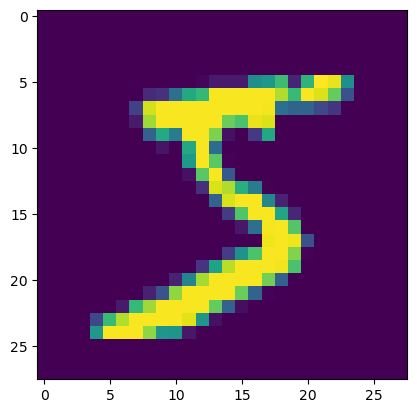

In [48]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

In [49]:
X_train = X_train/255.
X_test = X_test/255.

In [50]:
X_test[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [51]:
model = Sequential()
model.add(Flatten(input_shape = (28,28)))
model.add(Dense( 128, activation = 'relu'))
model.add(Dense( 10, activation = 'softmax'))

c:\Users\Ali\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(loss = 'sparse_categorical_crossentropy',optimizer = 'Adam')

In [54]:
model.fit(X_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 152s 95ms/step - loss: 0.2855 - val_loss: 0.1531
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 73s 48ms/step - loss: 0.1297 - val_loss: 0.1192
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - loss: 0.0887 - val_loss: 0.1013
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - loss: 0.0655 - val_loss: 0.0921
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - loss: 0.0510 - val_loss: 0.0944
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - loss: 0.0401 - val_loss: 0.0856
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 103s 50ms/step - loss: 0.0311 - val_loss: 0.0916
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 93s 57ms/step - loss: 0.0254 - val_loss: 0.0902
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 113s 37ms/step - loss: 0.0202 - val_loss: 0.0954
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - loss: 0.0164 - val_loss: 0.0948


In [55]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


In [56]:
y_pred = y_prob.argmax(axis = 1)

In [57]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test, y_pred)
print("Accuracy is : ", score)

Accuracy is :  0.977


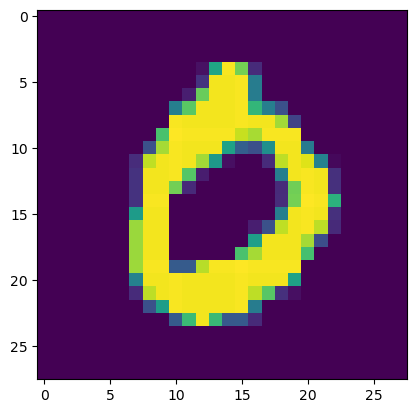

In [58]:
plt.imshow(X_test[3])

In [59]:
model.predict(X_test[3].reshape(1,28,28)).argmax(axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step


array([0])